# 1. Import Necessary Libraries

In [3]:
from  sklearn.datasets import load_iris
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# 2. Data Collection

In [5]:
load_iris()

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [21]:
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns = iris.feature_names)
iris_df["target"] = iris.target
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


# 3. Data Understanding

In [22]:
iris_df.shape

(150, 5)

In [23]:
iris_df["target"].value_counts() # check the class values of target column

target
0    50
1    50
2    50
Name: count, dtype: int64

In [9]:
iris_df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [10]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [24]:
X = iris.data

# 4. Applying Data Transformation Techniques

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled)
X_scaled

,0,1,2,3
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


In [26]:
X_scaled.mean().round(4),X_scaled.std().round(4)

(0   -0.0
 1   -0.0
 2   -0.0
 3   -0.0
 dtype: float64,
 0    1.0034
 1    1.0034
 2    1.0034
 3    1.0034
 dtype: float64)

# 5. Model Building - Build Cluster algorithm

In [27]:
clusters_new = KMeans(n_clusters=3, random_state=12)
clusters_new.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,12
,copy_x,True
,algorithm,'lloyd'


In [28]:
KMeans(n_clusters=3, random_state=12)


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,12
,copy_x,True
,algorithm,'lloyd'


In [29]:
clusters_new.labels_

array([2, 0, 0, 0, 2, 2, 2, 2, 0, 0, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2,
       2, 0, 2, 0, 2, 2, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

### Clustering is DONE here. Let's put this back to the original Dataset for further Data Mining Operations

# LEVEL 2: Attach Clusters to Dataset

In [32]:
iris_df["iris_level"] = clusters_new.labels_
iris_df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,iris_level
0,5.1,3.5,1.4,0.2,0,2
1,4.9,3.0,1.4,0.2,0,0
2,4.7,3.2,1.3,0.2,0,0
3,4.6,3.1,1.5,0.2,0,0
4,5.0,3.6,1.4,0.2,0,2
5,5.4,3.9,1.7,0.4,0,2
6,4.6,3.4,1.4,0.3,0,2
7,5.0,3.4,1.5,0.2,0,2
8,4.4,2.9,1.4,0.2,0,0
9,4.9,3.1,1.5,0.1,0,0


# Finding Cluster Centroids

In [33]:
clusters_new.cluster_centers_

array([[-1.32765367, -0.373138  , -1.13723572, -1.11486192],
       [ 0.57100359, -0.37176778,  0.69111943,  0.66315198],
       [-0.81623084,  1.31895771, -1.28683379, -1.2197118 ]])

In [35]:
X = pd.DataFrame(iris.data, columns=iris.feature_names)
X.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [36]:
X["iris_level"] = clusters_new.labels_
X.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_level
0,5.1,3.5,1.4,0.2,2
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,2
5,5.4,3.9,1.7,0.4,2
6,4.6,3.4,1.4,0.3,2
7,5.0,3.4,1.5,0.2,2
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


### Note: This is the Most Important Data Mining Step post Clustering, but before we give labels

In [37]:
X.groupby("iris_level").agg(['mean'])

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
,mean,mean,mean,mean
iris_level,,,,
0,4.747619,2.895238,1.757143,0.352381
1,6.314583,2.895833,4.973958,1.703125
2,5.169697,3.630303,1.493939,0.272727


In [38]:
X.groupby("iris_level").agg(['min','max'])

sepal length (cm)      sepal width (cm)      petal length (cm)  \
                         min  max              min  max               min   
iris_level                                                                  
0                        4.3  5.1              2.0  3.2               1.1   
1                        4.9  7.9              2.2  3.8               3.5   
2                        4.6  5.8              3.3  4.4               1.0   

                petal width (cm)       
            max              min  max  
iris_level                             
0           3.5              0.1  1.1  
1           6.9              1.0  2.5  
2           1.9              0.1  0.6

In [39]:
cluster_names = {0: "Setosa",
                 1: "Versicolor",
                 2: "Virginica"}
X["Category"] = X["iris_level"].map(cluster_names)

In [40]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_level,Category
0,5.1,3.5,1.4,0.2,2,Virginica
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,2,Virginica
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,1,Versicolor
146,6.3,2.5,5.0,1.9,1,Versicolor
147,6.5,3.0,5.2,2.0,1,Versicolor
148,6.2,3.4,5.4,2.3,1,Versicolor


## LEVEL 3: Now it's time to Transition to Supervised Learning

### The End!!

### But, how to decide the Optimal Number of Clusters?

In [41]:
clusters_new = KMeans(n_clusters=3, random_state=12)
clusters_new.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,12
,copy_x,True
,algorithm,'lloyd'


In [42]:
clusters_new.inertia_

191.02473685317966

#### The K-means algorithm aims to choose centroids that minimise the inertia, or within-cluster sum-of-squares criterion:

In [43]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,random_state=1234)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [44]:
X_scaled

,0,1,2,3
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


In [45]:
wcss

[600.0000000000001,
 222.36170496502305,
 139.8204963597498,
 114.55684421262919,
 105.2217716938895,
 97.00638392392854,
 73.58691759143824,
 63.255322931818654,
 55.1757409225933,
 47.32384868233779]

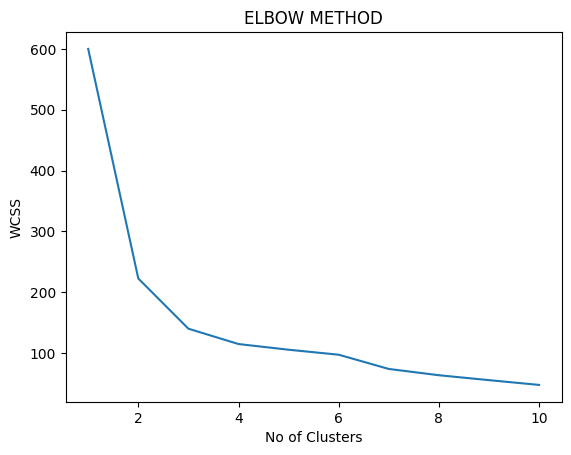

In [46]:
plt.plot(range(1,11),wcss)
plt.title('ELBOW METHOD')
plt.xlabel('No of Clusters')
plt.ylabel('WCSS')
plt.show()